In [11]:
import numpy as np

def convolove2d(image, kernel, stride=1, padding=0):

    image = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode='constant'
    )

    H, W = image.shape
    kH, kW = kernel.shape

    outH = (H - kH)//stride + 1
    outW = (W - kW)//stride + 1

    output = np.zeros((outH, outW))

    for i in range(outH):
        for j in range(outW):

            region = image[
                i*stride:i*stride+kH,
                j*stride:j*stride+kW
            ]

            output[i, j] = np.sum(region * kernel)

    return output


def max_pool2d(image, pool_size=2, stride=2):

    H, W = image.shape

    outH = (H - pool_size)//stride + 1
    outW = (W - pool_size)//stride + 1

    output = np.zeros((outH, outW))

    for i in range(outH):
        for j in range(outW):

            region = image[
                i*stride:i*stride+pool_size,
                j*stride:j*stride+pool_size
            ]

            output[i, j] = np.max(region)

    return output


def avg_pool2d(image, pool_size=2, stride=2):

    H, W = image.shape

    outH = (H - pool_size)//stride + 1
    outW = (W - pool_size)//stride + 1

    output = np.zeros((outH, outW))

    for i in range(outH):
        for j in range(outW):

            region = image[
                i*stride:i*stride+pool_size,
                j*stride:j*stride+pool_size
            ]

            output[i, j] = np.mean(region)

    return output

import numpy as np

img = np.array([
    [1,2,3],
    [4,5,6],
    [7,8,9]
])

kernel = np.array([
    [0,0,0],
    [0,1,0],
    [0,0,0]
])

result = convolove2d(img, kernel, padding=1)

print(result)


[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]


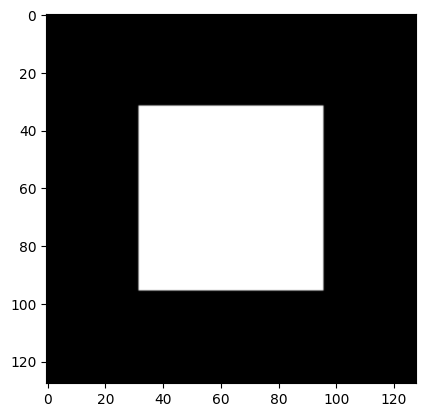

In [2]:
import numpy as np
import matplotlib.pyplot as plt
test_image = np.zeros((128,128))

test_image[32:96,32:96] = 1

plt.imshow(test_image,cmap='gray')
plt.show()


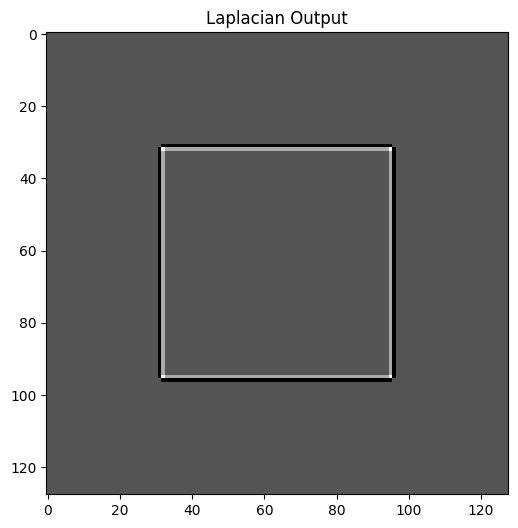

In [12]:
laplacian = np.array([
    [0,-1,0],
    [-1,4,-1],
    [0,-1,0]
])

output = convolove2d(
    test_image,
    laplacian,
    stride=1,
    padding=1
)

plt.figure(figsize=(6,6))
plt.imshow(output,cmap='gray')
plt.title("Laplacian Output")
plt.show()

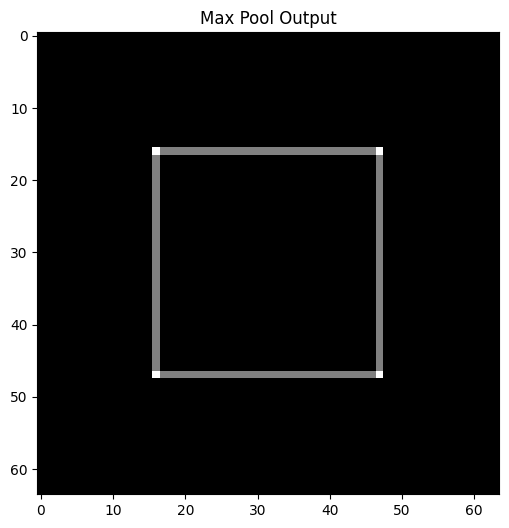

In [4]:
pooled = max_pool2d(output, pool_size=2, stride=2)

plt.figure(figsize=(6,6))
plt.imshow(pooled, cmap='gray')
plt.title("Max Pool Output")
plt.show()


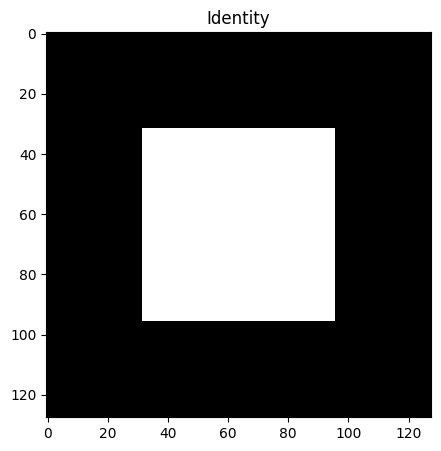

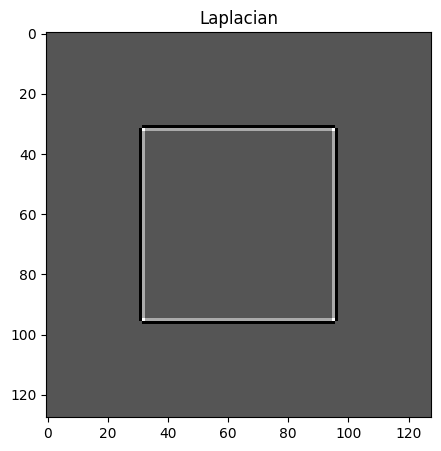

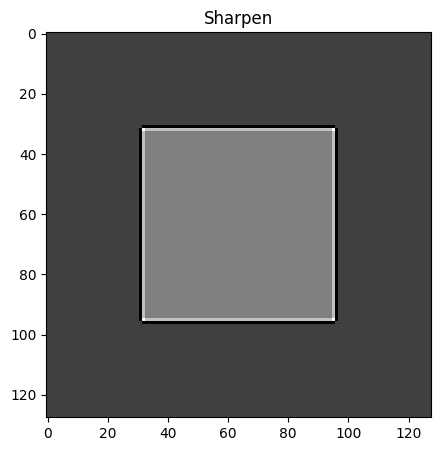

In [13]:
kernels = {
    "Identity": np.array([[0,0,0],[0,1,0],[0,0,0]]),

    "Laplacian": np.array([[0,-1,0],
                           [-1,4,-1],
                           [0,-1,0]]),

    "Sharpen": np.array([[0,-1,0],
                         [-1,5,-1],
                         [0,-1,0]])
}

for name,kernel in kernels.items():

    conv = convolove2d(test_image,kernel,padding=1)

    plt.figure(figsize=(5,5))
    plt.imshow(conv,cmap='gray')
    plt.title(name)
    plt.show()

In [6]:
sobel_horizontal = np.array([
    [-1,-2,-1],
    [ 0, 0, 0],
    [ 1, 2, 1]
])

sobel_vertical = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

gaussian_blur = (1/16) * np.array([
    [1,2,1],
    [2,4,2],
    [1,2,1]
])

emboss = np.array([
    [-2,-1,0],
    [-1, 1,1],
    [ 0, 1,2]
])

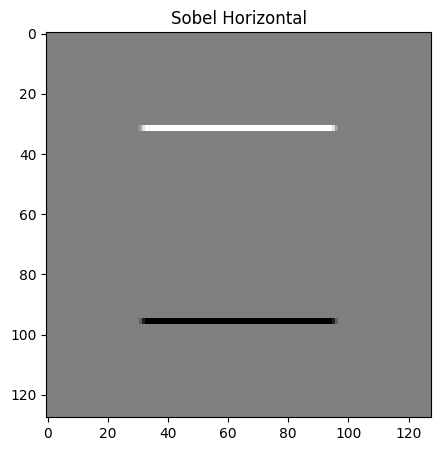

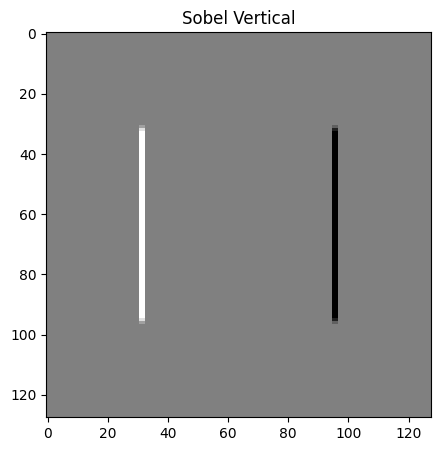

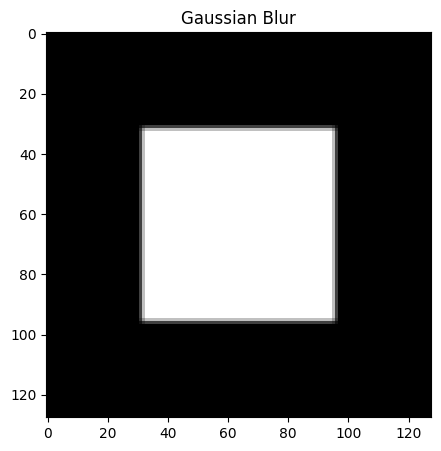

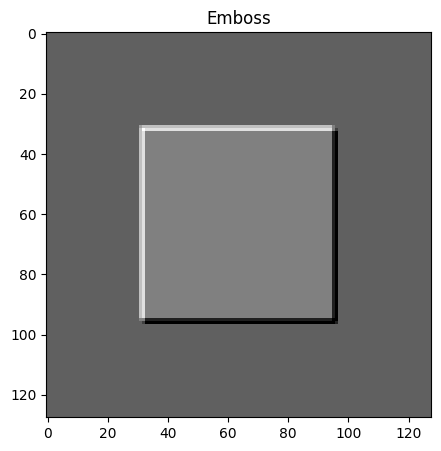

In [14]:
kernels = {
    "Sobel Horizontal": sobel_horizontal,
    "Sobel Vertical": sobel_vertical,
    "Gaussian Blur": gaussian_blur,
    "Emboss": emboss
}

for name, kernel in kernels.items():

    conv = convolove2d(
        test_image,
        kernel,
        padding=1
    )

    plt.figure(figsize=(5,5))
    plt.imshow(conv, cmap='gray')
    plt.title(name)
    plt.show()

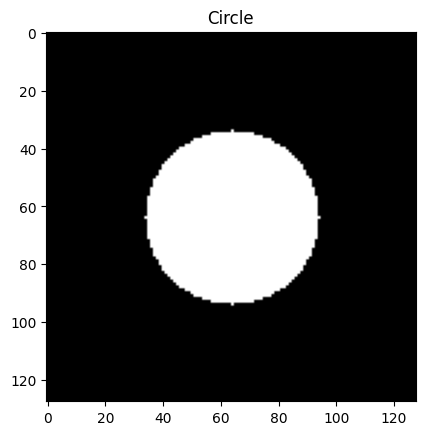

In [15]:
import numpy as np
import matplotlib.pyplot as plt

circle = np.zeros((128,128))

y,x = np.ogrid[:128,:128]
mask = (x-64)**2 + (y-64)**2 <= 30**2

circle[mask] = 1

plt.imshow(circle,cmap='gray')
plt.title("Circle")
plt.show()

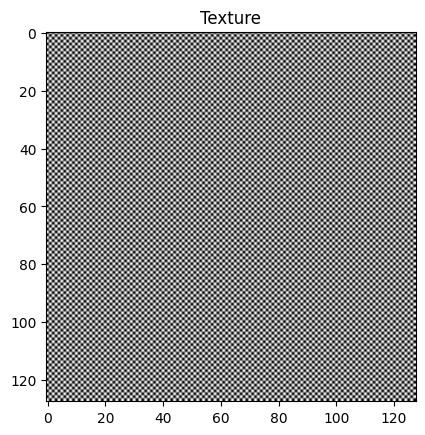

In [16]:
texture = np.zeros((128,128))

for i in range(128):
    for j in range(128):
        texture[i,j] = (i+j)%2

plt.imshow(texture,cmap='gray')
plt.title("Texture")
plt.show()

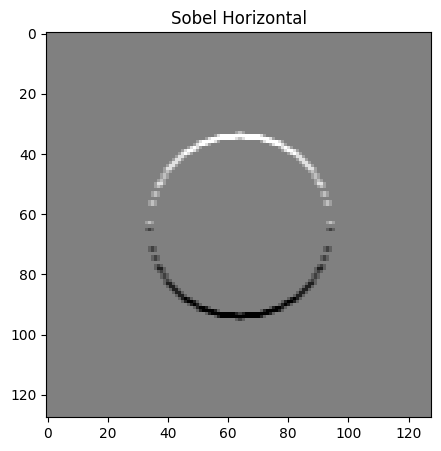

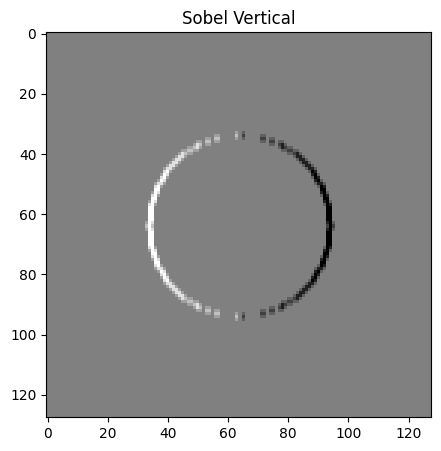

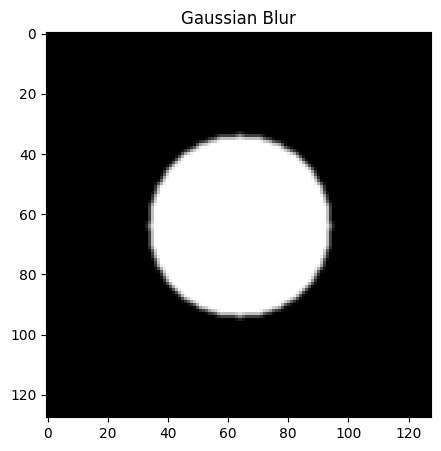

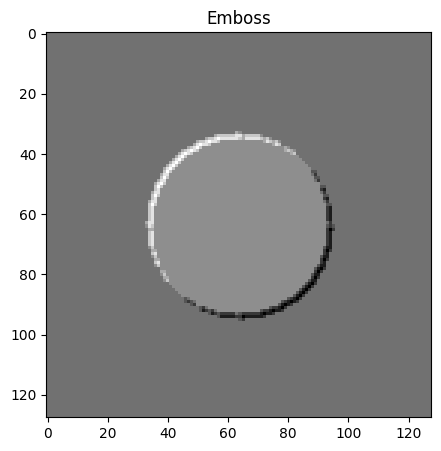

In [17]:
kernels = {
    "Sobel Horizontal": sobel_horizontal,
    "Sobel Vertical": sobel_vertical,
    "Gaussian Blur": gaussian_blur,
    "Emboss": emboss
}

for name, kernel in kernels.items():

    conv = convolove2d(
        circle,
        kernel,
        padding=1
    )

    plt.figure(figsize=(5,5))
    plt.imshow(conv, cmap='gray')
    plt.title(name)
    plt.show()

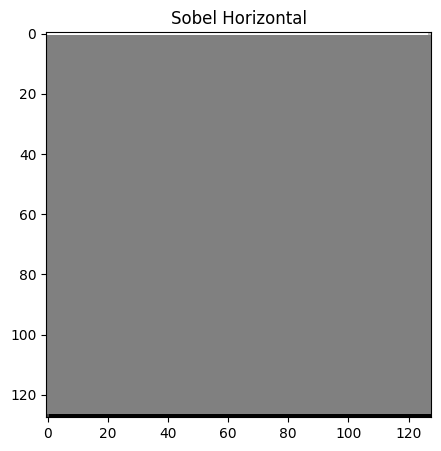

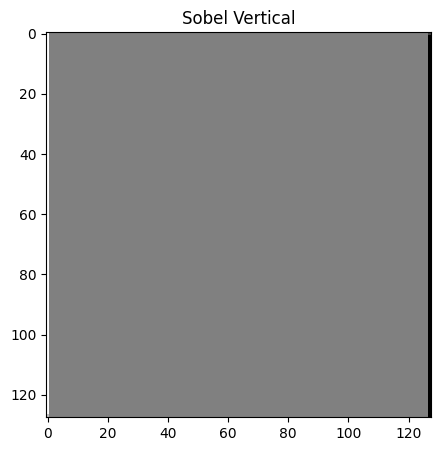

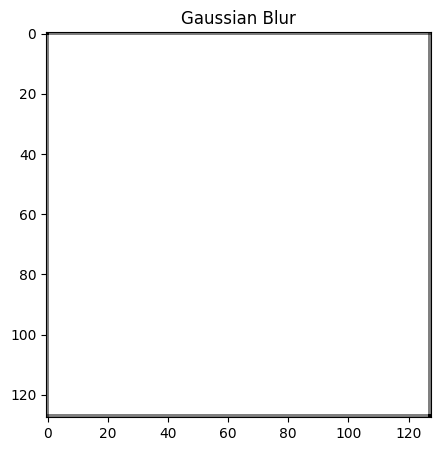

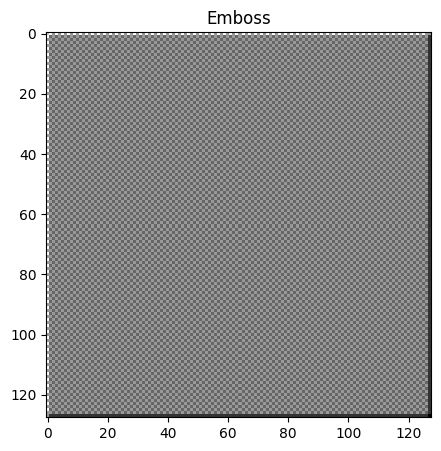

In [18]:
kernels = {
    "Sobel Horizontal": sobel_horizontal,
    "Sobel Vertical": sobel_vertical,
    "Gaussian Blur": gaussian_blur,
    "Emboss": emboss
}

for name, kernel in kernels.items():

    conv = convolove2d(
        texture,
        kernel,
        padding=1
    )

    plt.figure(figsize=(5,5))
    plt.imshow(conv, cmap='gray')
    plt.title(name)
    plt.show()

In [19]:
def avg_pool2d(image,pool_size=2,stride=2):

    H,W = image.shape

    outH = (H-pool_size)//stride + 1
    outW = (W-pool_size)//stride + 1

    output = np.zeros((outH,outW))

    for i in range(outH):
        for j in range(outW):

            region = image[
                i*stride:i*stride+pool_size,
                j*stride:j*stride+pool_size
            ]

            output[i,j] = np.mean(region)

    return output

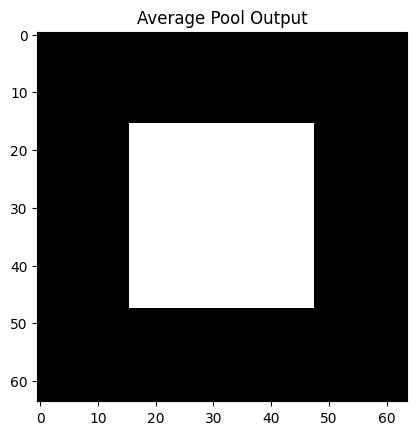

In [20]:
avg_output = avg_pool2d(test_image)

plt.imshow(avg_output,cmap='gray')
plt.title("Average Pool Output")
plt.show()